# Remote Sensing: Land Surface Temperature and Planetary Computer Imagery

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ByMaxAnjos/LCZ4py/blob/main/notebooks/general/04_remote_sensing_lst_pc.en.ipynb)

**Learning objective**: download a Land Surface Temperature (LST) time series from Microsoft Planetary Computer, and separately pull multispectral imagery (Sentinel-2) from the same Planetary Computer catalog — both cropped to an LCZ map's footprint so they line up pixel-for-pixel with the LCZ classes computed in earlier notebooks.

## Why Land Surface Temperature, and why crop to the LCZ footprint first

Land Surface Temperature (LST) is the primary satellite-observable proxy for **Surface Urban Heat Island (SUHI)** studies. Unlike air temperature (measured canopy-layer, at ~2 m, by weather stations — the subject of the `local/` notebook series later in this tutorial), LST is the *radiometric skin temperature* of whatever the satellite sensor sees: roofs, roads, tree canopy, bare soil, water. It responds almost instantly to solar heating and surface material properties (albedo, emissivity, thermal admittance), which makes it an excellent lens for the surface-energy-balance differences that the Local Climate Zone (LCZ) scheme (Stewart & Oke, 2012) was designed to capture: a compact high-rise LCZ 1 and a low-rise open LCZ 6 absorb and re-radiate solar energy very differently, and LST makes that difference directly visible.

**Why crop to the LCZ map's footprint before doing anything else?** Every downstream LCZ-stratified analysis — computing mean LST per class, running `lcz_uhi_surface` (Surface UHI intensity), or feeding LST into a spectral-index workflow — requires the LST raster and the LCZ classification raster to sit on **exactly the same grid**: same extent, same resolution, same coordinate reference system, pixel-for-pixel. If they are not spatially aligned, any per-class statistic silently mixes LST from one location with an LCZ label from another. `lcz_get_lst` and `lcz_get_planetary_computer` both take the LCZ map's GeoTIFF as their reference grid (`x=`) and reproject/resample whatever they download onto it before returning anything, so the alignment problem is solved once, at ingestion, rather than repeatedly downstream.

**Two LST sources, two very different trade-offs:**

- **GOES-R ABI-L2-LST** (`source="goes"`) is a geostationary satellite product covering the Americas only (CONUS-centric), at a coarse ~2 km native resolution — but it scans the same disk every ~10-15 minutes, so a single day can be sampled at almost any local hour (`target_hour=`). That temporal density is valuable for diurnal SUHI dynamics (e.g. how the heat island peaks in the afternoon and reverses at night), but the coarse pixel size and the Americas-only footprint limit its use for global or fine-grained neighborhood-scale analysis.
- **Sentinel-3 SLSTR LST** (`source="sentinel3"`) is a polar-orbiting sensor with **global coverage** at a finer ~1 km resolution, but only 1-2 overpasses per day at variable local times — coarser temporal sampling in exchange for working anywhere on Earth. This is the source we use below, precisely because it works for any city, not only ones inside the GOES view.

**Why Planetary Computer access to Sentinel-2/Landsat matters next**: LST alone tells us *how hot* a surface is, but not *why* — is it because of vegetation cover, built-up density, soil moisture, or surface albedo? Answering that requires multispectral reflectance bands (red, NIR, SWIR, ...), which is exactly what `lcz_get_planetary_computer` retrieves from Sentinel-2 or Landsat. Those bands feed directly into spectral indices (NDVI, NDBI, NDWI, and friends) — the subject of the next notebook in this series — which in turn explain *why* an LCZ class runs hot or cool. This notebook, then, sits at the hinge between "where is it hot" (LST) and "what is driving that" (spectral indices from optical imagery).

In [1]:
!pip -q install "LCZ4py[all] @ git+https://github.com/ByMaxAnjos/LCZ4py.git"


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /Applications/QGIS.app/Contents/MacOS/bin/python3 -m pip install --upgrade pip
ERROR: Package 'lcz4py' requires a different Python: 3.9.5 not in '>=3.10'


## 1 — Download a reference LCZ map

We use **Juiz de Fora** (Liechtenstein) as the reference city throughout — a tiny bounding box keeps every raster small, so both the LST and Planetary Computer downloads below stay fast. `lcz_get_map` returns the path to a clipped LCZ GeoTIFF; that path is the `x=` argument every function below uses as its reference grid.

In [2]:
from LCZ4py import lcz_get_map

map_path = lcz_get_map(city="Juiz de Fora")
print("LCZ map:", map_path)

13:37:33 - LCZ4py._internal._lcz_map_engine - INFO - Streaming COG and clipping to geometry...


13:37:41 - rasterio._env - WARNING - CPLE_IllegalArg in tmpo8dr3159.tif: BLOCKXSIZE can only be used with TILED=YES


13:37:41 - LCZ4py._internal._lcz_map_engine - INFO - Saved to clipped cache.


LCZ map: /Users/co2map/.lcz4r_cache/clipped_c7031cb44f08aaf6.tif


## 2 — `lcz_get_lst`: a Sentinel-3 LST time series

`lcz_get_lst(x, source, start_date, end_date, ...)` downloads a **daily LST stack** — one band per date, `(n_days, H, W)` — cropped and resampled onto the LCZ map's grid. Key parameters:

- `source`: `"goes"` (Americas, ~2 km, high revisit), `"sentinel3"` (global, ~1 km, 1-2 overpasses/day), or `"both"` (GOES first, Sentinel-3 fallback per day).
- `start_date`/`end_date`: ISO dates, inclusive. We use a short 5-day window here to keep the download quick — Sentinel-3 revisits often enough that a handful of days usually yields at least one usable scene per day.
- `target_hour`: local-solar hour to target for the GOES pick (ignored for Sentinel-3, which returns whatever overpass(es) exist for the day).
- `units`: `"C"` (default) or `"K"`. The on-disk cache always stores Kelvin, so switching `units` between calls never triggers a re-download.

It returns an `LCZLSTResult` with `.array` (the stack), `.dates` (ISO date per band), `.units`, and `.path` (the cache GeoTIFF, handy for `lcz_plot_map` or `lcz_uhi_surface` downstream). Juiz de Fora sits well outside the GOES CONUS view, so `source="sentinel3"` is the only option here — which is also the point: it is the source that works for *any* city on Earth.

In [3]:
from LCZ4py import lcz_get_lst

lst = lcz_get_lst(
    map_path,
    source="sentinel3",
    start_date="2024-06-01",
    end_date="2024-06-05",
    units="C",
    cache=True,
)

print("array shape (days, H, W):", lst.array.shape)
print("units:", lst.units)
print("dates:", lst.dates)
import numpy as np
for d, band in zip(lst.dates, lst.array):
    print(f"  {d}: mean={np.nanmean(band):.2f} {lst.units}, valid px={int(np.isfinite(band).sum())}")

13:37:41 - LCZ4py.general.lcz_get_lst - INFO - Using cached LST stack: /Users/co2map/.lcz4r_cache/lst_stack_cf69bc6884efbaf6.tif


array shape (days, H, W): (2, 534, 601)
units: C
dates: ['2024-06-02', '2024-06-04']
  2024-06-02: mean=11.46 C, valid px=155441
  2024-06-04: mean=15.51 C, valid px=20326


**Reading the output**: each row above is one day's mean LST over Juiz de Fora's LCZ footprint, plus a valid-pixel count. A day with a low valid-pixel count (or no printed row at all — `lcz_get_lst` silently skips days with no usable scene) means cloud cover or no overpass reached that pixel that day; this is normal for a small area and a short window, and is exactly why SUHI studies usually composite over weeks-to-months rather than trusting a single date. The Kelvin-vs-Celsius distinction only affects the returned array — the on-disk cache is always Kelvin, so re-running with a different `units=` is instant.

## 3 — Visualizing the LST stack with `lcz_plot_map` (`data_type="continuous"`)

`lcz_plot_map` was introduced in notebook 02 for categorical LCZ class maps. It also has a **continuous-raster mode** (`data_type="continuous"`, or `"auto"` which detects a float-dtype stack automatically) for exactly this kind of output: a multi-band GeoTIFF where each band is a numeric field rather than an LCZ code. Pass `band=` to pick which date to render — by index, or by matching a band description (an ISO date string, in this case). The `colorscale=` parameter (default `"RdBu_r"`) controls the continuous color ramp; a diverging or sequential thermal ramp both work well for LST.

In [4]:
from LCZ4py import lcz_plot_map

plot_lst = lcz_plot_map(
    lst.path,
    data_type="continuous",
    band=lst.dates[0],
    title="Sentinel-3 LST — Juiz de Fora",
    colorscale="inferno",
)
plot_lst.fig.show()

**Interpretation**: the map renders the raw Kelvin values from the cache file (the colorbar title reflects the `units` tag written to the GeoTIFF) as a continuous heatmap over Juiz de Fora's footprint — no LCZ-class legend, just a color ramp with a colorbar. Warmer colors mark valley floor / built-up pixels; cooler colors mark higher-elevation or vegetated terrain. This is the single-date visual counterpart to the per-day means printed in §2 — useful for spotting spatial patterns (e.g. a warm river valley, a cool forested slope) that a single mean number cannot show.

## 4 — `lcz_list_pc_assets`: discover available bands before downloading

Microsoft Planetary Computer hosts 100+ STAC collections. `lcz_get_planetary_computer` ships curated shortcuts (`PC_COLLECTIONS`) for common ones — `"sentinel-2-l2a"`, `"landsat"`, `"worldcover"`, `"biodiversity"`, `"elevation"`, `"surface-water"`, `"landcover-cci"` — each with a sensible default asset list. Before downloading anything (especially for a collection *not* in that shortcut list), `lcz_list_pc_assets(collection, x)` queries the first matching STAC item over the LCZ map's bounding box and returns `{asset_key: title}` — so you know exactly which band names to pass as `assets=`.

In [5]:
from LCZ4py import lcz_list_pc_assets

assets = lcz_list_pc_assets("sentinel-2-l2a", map_path)
for key, title in assets.items():
    print(f"{key:12s} {title}")

AOT          Aerosol optical thickness (AOT)
B01          Band 1 - Coastal aerosol - 60m
B02          Band 2 - Blue - 10m
B03          Band 3 - Green - 10m
B04          Band 4 - Red - 10m
B05          Band 5 - Vegetation red edge 1 - 20m
B06          Band 6 - Vegetation red edge 2 - 20m
B07          Band 7 - Vegetation red edge 3 - 20m
B08          Band 8 - NIR - 10m
B09          Band 9 - Water vapor - 60m
B11          Band 11 - SWIR (1.6) - 20m
B12          Band 12 - SWIR (2.2) - 20m
B8A          Band 8A - Vegetation red edge 4 - 20m
SCL          Scene classfication map (SCL)
WVP          Water vapour (WVP)
visual       True color image
safe-manifest SAFE manifest
granule-metadata Granule metadata
inspire-metadata INSPIRE metadata
product-metadata Product metadata
datastrip-metadata Datastrip metadata
tilejson     TileJSON with default rendering
rendered_preview Rendered preview


**Reading the output**: each row is one Sentinel-2 band available for this location — e.g. `B04` (red), `B03` (green), `B02` (blue), `B08` (NIR), plus SWIR bands, scene-classification layers, and QA masks. `PC_COLLECTIONS` already defaults `"sentinel-2-l2a"` to `["B04", "B03", "B02", "B08"]` (red/green/blue/NIR) — enough for a true-color composite plus the NIR band spectral indices need — but this listing is what you'd consult to add SWIR bands (e.g. `"B11"`) for indices like NDBI or NDMI in the next notebook.

## 5 — `lcz_get_planetary_computer`: Sentinel-2 imagery over the LCZ footprint

`lcz_get_planetary_computer(x, collection, assets=None, start_date=None, end_date=None, max_cloud_cover=30.0, max_items=10, ...)` searches the STAC catalog for the given `collection`, filters by cloud cover (for optical collections that expose it), and mosaics up to `max_items` candidate scenes (best-cloud-cover-first, first-valid-pixel-wins) onto the LCZ map's grid — the same reproject-and-align pattern as `lcz_get_lst`. Key parameters:

- `collection`: a `PC_COLLECTIONS` shortcut (`"sentinel-2-l2a"` here) or any raw Planetary Computer collection id plus explicit `assets=`.
- `start_date`/`end_date`: required together for time-varying collections. We use a 3-month window (`max_items=3`) to give the cloud-cover filter enough candidates without downloading dozens of scenes.
- `max_cloud_cover`: maximum `eo:cloud_cover` percentage, filtered server-side.
- `max_items`: how many candidate scenes to mosaic per asset — kept small (2-3) here to stay fast; a mountainous, tile-boundary-straddling area like Juiz de Fora may need more than one scene to fully cover the footprint.

It returns an `LCZPCResult` with `.array` (`(n_assets, H, W)`), `.bands` (band name per array slice), `.item_ids` (which STAC scenes contributed), and `.path` (cache GeoTIFF).

In [6]:
from LCZ4py import lcz_get_planetary_computer

s2 = lcz_get_planetary_computer(
    map_path,
    collection="sentinel-2-l2a",
    start_date="2024-06-01",
    end_date="2024-08-31",
    max_cloud_cover=20,
    max_items=3,
)

print("bands:", s2.bands)
print("array shape (bands, H, W):", s2.array.shape)
print("STAC items used:", s2.item_ids)
import numpy as np
valid_px = int(np.isfinite(s2.array[0]).sum())
print("footprint coverage (band 0, valid px):", valid_px, "/", s2.array[0].size)

13:37:44 - LCZ4py.general.lcz_get_planetary_computer - INFO - Using cached Planetary Computer stack: /Users/co2map/.lcz4r_cache/pc_sentinel-2-l2a_09d4d539c21f7d51.tif


bands: ['B04', 'B03', 'B02', 'B08']
array shape (bands, H, W): (4, 534, 601)
STAC items used: ['S2A_MSIL2A_20240820T130241_R095_T23KPR_20240820T160756', 'S2A_MSIL2A_20240820T130241_R095_T23KPS_20240820T160756']
footprint coverage (band 0, valid px): 155441 / 320934


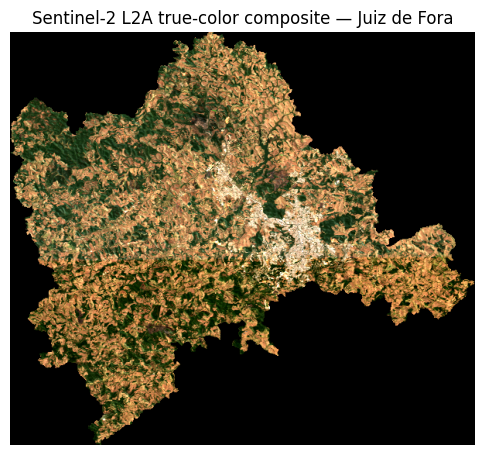

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# bands are ["B04", "B03", "B02", "B08"] = red, green, blue, NIR
def to_rgb(arr, band_idx=(0, 1, 2)):
    rgb = np.stack([arr[i] for i in band_idx], axis=-1)
    lo, hi = np.nanpercentile(rgb, [2, 98])
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-9), 0, 1)
    return np.nan_to_num(rgb)

plt.figure(figsize=(6, 6))
plt.imshow(to_rgb(s2.array))
plt.title("Sentinel-2 L2A true-color composite — Juiz de Fora")
plt.axis("off")
plt.show()

**Interpretation**: the true-color composite shows Juiz de Fora's Alpine valley setting — built-up areas along the valley floor, forested slopes, and bare rock at higher elevation, all cropped to exactly the same footprint as the LCZ map and the LST stack above. `item_ids` reveals whether one Sentinel-2 tile covered the whole area or several were mosaicked (common near UTM-zone or tile boundaries). This four-band stack (`B04`/`B03`/`B02`/`B08`) is the direct input the next notebook's `lcz_get_indices` uses to compute NDVI, NDBI, and other spectral indices — the bridge from "here is the reflectance data" to "here is what it tells us about vegetation, built-up density, and moisture."

## Conclusion

This notebook covered two complementary satellite data streams, both aligned to an LCZ map's footprint before any analysis: `lcz_get_lst` for Land Surface Temperature (the primary SUHI observable, trading off GOES's high revisit and Americas-only coverage against Sentinel-3's global reach and coarser revisit), and `lcz_get_planetary_computer` for keyless access to Sentinel-2/Landsat multispectral imagery via Microsoft's STAC catalog, with `lcz_list_pc_assets` to discover band names first. Cropping both to the same LCZ grid guarantees that any later per-class statistic (e.g. `lcz_uhi_surface`, `lcz_cal_indices`) compares like with like, pixel-for-pixel.

**Previous**: [`03_morphological_parameters`](03_morphological_parameters.en.ipynb) — morphological parameters per LCZ pixel.

**Next**: [`05_spectral_indices`](05_spectral_indices.en.ipynb) — turning the Sentinel-2 bands downloaded here into NDVI, NDBI, and other spectral indices, and summarizing them per LCZ class.